In [8]:
# ==========================================
# Cell 1: Imports and Environment Setup
# ==========================================
from __future__ import annotations

import json
import re
import time
import warnings
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
    calinski_harabasz_score
)

# 1. Classification
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    Perceptron,
    PassiveAggressiveClassifier
)
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

# 2. Regression
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    HuberRegressor,
    SGDRegressor,
    PoissonRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

# 3. Clustering
from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    BisectingKMeans,
    AgglomerativeClustering,
    Birch,
    DBSCAN,
    OPTICS,
    MeanShift,
    SpectralClustering
)
from sklearn.mixture import GaussianMixture

# 4. Dimensionality Reduction
from sklearn.decomposition import (
    PCA,
    IncrementalPCA,
    KernelPCA,
    TruncatedSVD,
    NMF,
    FastICA,
    FactorAnalysis
)
from sklearn.manifold import (
    Isomap,
    LocallyLinearEmbedding,
    MDS
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = Path("ColabData")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_TARGET_COLUMN = "Diabetes_012"
TEST_SIZE = 0.20
MAX_HEAVY_SAMPLES = 1000

In [9]:
# ==========================================
# Cell 3: Interactive Google Drive Link Input
# ==========================================

#@title 🔗 Enter Your Google Drive Links Here
#@markdown Enter one or more links (you can provide multiple links separated by spaces or new lines):
MY_DATASET_LINKS = "https://drive.google.com/file/d/1oQnqcw3RHFspA8z02r-nUSUw_PSk4e_a/view?usp=drive_link    https://drive.google.com/file/d/1YB7OzAHrLEoBPhZpQFNR5Tt7xEYhNJhm/view?usp=drive_link    https://drive.google.com/file/d/1caYPh6jlFi8Pxjn9uliawwS9SMphM_Vz/view?usp=drive_link"


def extract_all_drive_ids(text: str) -> list[str]:
    """Extract all File IDs from the text regardless of the invocation method."""
    ids = re.findall(r'(?:/d/|[?&]id=)([A-Za-z0-9_-]+)', text)
    return list(dict.fromkeys(ids))  # Remove duplicates while preserving order


def load_user_datasets(
    links_text: str,
    download_dir: Path
) -> dict[str, pd.DataFrame]:

    file_ids = extract_all_drive_ids(links_text)

    if not file_ids:
        raise ValueError(
            "❌ You did not enter any valid Google Drive links in the field above! "
            "Please paste the links and rerun the cell."
        )

    loaded_datasets = {}

    print(f"✅ {len(file_ids)} dataset link(s) detected. Starting download...\n")

    for idx, file_id in enumerate(file_ids, start=1):

        ds_name = f"Dataset_{idx}_ID_{file_id[:6]}"
        file_path = download_dir / f"{ds_name}.csv"

        try:
            if not file_path.exists():
                print(
                    f"[{idx}/{len(file_ids)}] "
                    f"Downloading file from Google Drive (ID: {file_id})..."
                )

                gdown.download(
                    id=file_id,
                    output=str(file_path),
                    quiet=False
                )
            else:
                print(
                    f"[{idx}/{len(file_ids)}] "
                    f"File already exists in memory: {file_path.name}"
                )

            df = pd.read_csv(file_path)
            loaded_datasets[ds_name] = df

            print(
                f"   ✓ Successfully loaded {ds_name}: "
                f"({df.shape[0]:,} rows × {df.shape[1]} columns)\n"
            )

        except Exception as e:
            print(
                f"   ❌ Failed to read {ds_name}: {e}\n"
            )

    return loaded_datasets


# Load the files you provided
datasets = load_user_datasets(MY_DATASET_LINKS, DATA_DIR)

✅ 3 dataset link(s) detected. Starting download...

[1/3] File already exists in memory: Dataset_1_ID_1oQnqc.csv
   ✓ Successfully loaded Dataset_1_ID_1oQnqc: (253,680 rows × 22 columns)

[2/3] File already exists in memory: Dataset_2_ID_1YB7Oz.csv
   ✓ Successfully loaded Dataset_2_ID_1YB7Oz: (70,692 rows × 22 columns)

[3/3] File already exists in memory: Dataset_3_ID_1caYPh.csv
   ✓ Successfully loaded Dataset_3_ID_1caYPh: (253,680 rows × 22 columns)



In [10]:

# ==========================================
# Cell 4: Data Cleaning and Preprocessing
# ==========================================
def preprocess_dataset(df: pd.DataFrame, target_col: str):
    missing_tokens = ['', 'nan', 'null', 'none', '?']
    df_clean = df.copy()

    # Automatically identify the target column if the default name is not found
    actual_target = target_col if target_col in df_clean.columns else df_clean.columns[-1]

    # Handle missing values
    for column in df_clean.columns:
        numeric = pd.to_numeric(df_clean[column], errors='coerce')
        if numeric.notna().sum() == len(df_clean) - df_clean[column].astype(str).str.strip().isin(missing_tokens).sum():
            fill_value = numeric.mean()
            df_clean[column] = numeric.fillna(fill_value)
        else:
            mode = df_clean[column].replace(missing_tokens, np.nan).mode()
            df_clean[column] = df_clean[column].replace(missing_tokens, np.nan).fillna(
                mode.iloc[0] if len(mode) else 'unknown'
            )

    X_df = df_clean.drop(columns=[actual_target]).apply(pd.to_numeric, errors='coerce').fillna(0)
    y = pd.to_numeric(df_clean[actual_target], errors='coerce').fillna(0).astype(int).to_numpy()
    X = X_df.to_numpy(dtype=float)

    # Split the data
    stratify_param = y if len(np.unique(y)) > 1 and len(np.unique(y)) < len(y) // 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify_param
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, actual_target



In [11]:
# ==========================================
# Cell 5: Definition of the 50 Algorithms (4 Categories)
# ==========================================
def classification_models() -> dict[str, Any]:
    return {
        "01 Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "02 Ridge Classifier": RidgeClassifier(),
        "03 SGD Classifier": SGDClassifier(random_state=RANDOM_STATE),
        "04 Perceptron": Perceptron(random_state=RANDOM_STATE),
        "05 Passive Aggressive": PassiveAggressiveClassifier(random_state=RANDOM_STATE),
        "06 Linear SVC": LinearSVC(random_state=RANDOM_STATE, dual='auto'),
        "07 SVC RBF": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        "08 K-Nearest Neighbors": KNeighborsClassifier(),
        "09 Gaussian Naive Bayes": GaussianNB(),
        "10 Multinomial Naive Bayes": MultinomialNB(),
        "11 Bernoulli Naive Bayes": BernoulliNB(),
        "12 Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "13 Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        "14 Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        "15 HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    }

def regression_models() -> dict[str, Any]:
    return {
        "16 Linear Regression": LinearRegression(),
        "17 Ridge Regression": Ridge(),
        "18 Lasso Regression": Lasso(max_iter=5000),
        "19 Elastic Net": ElasticNet(max_iter=5000, random_state=RANDOM_STATE),
        "20 Huber Regressor": HuberRegressor(max_iter=1000),
        "21 SGD Regressor": SGDRegressor(random_state=RANDOM_STATE, max_iter=2000),
        "22 Support Vector Regression": SVR(),
        "23 K-Nearest Neighbors Regressor": KNeighborsRegressor(),
        "24 Decision Tree Regressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "25 Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        "26 Extra Trees Regressor": ExtraTreesRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        "27 HistGradientBoosting Regressor": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "28 Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "29 AdaBoost Regressor": AdaBoostRegressor(random_state=RANDOM_STATE),
        "30 Poisson Regressor": PoissonRegressor(max_iter=1000),
    }

def clustering_models(n_samples: int) -> dict[str, Any]:
    k = max(2, min(3, n_samples - 1))
    return {
        "31 K-Means": KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10),
        "32 Mini-Batch K-Means": MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10),
        "33 Bisecting K-Means": BisectingKMeans(n_clusters=k, random_state=RANDOM_STATE),
        "34 Agglomerative Clustering": AgglomerativeClustering(n_clusters=k),
        "35 Birch": Birch(n_clusters=k),
        "36 DBSCAN": DBSCAN(eps=0.5, min_samples=5),
        "37 OPTICS": OPTICS(min_samples=5),
        "38 Mean Shift": MeanShift(),
        "39 Spectral Clustering": SpectralClustering(n_clusters=k, random_state=RANDOM_STATE, assign_labels="kmeans"),
        "40 Gaussian Mixture": GaussianMixture(n_components=k, random_state=RANDOM_STATE),
    }

def dimensionality_reduction_models(n_features: int, n_samples: int) -> dict[str, Any]:
    components = max(1, min(2, n_features, n_samples))
    return {
        "41 PCA": PCA(n_components=components, random_state=RANDOM_STATE),
        "42 Incremental PCA": IncrementalPCA(n_components=components),
        "43 Kernel PCA": KernelPCA(n_components=components, kernel="rbf", random_state=RANDOM_STATE),
        "44 Truncated SVD": TruncatedSVD(n_components=components, random_state=RANDOM_STATE),
        "45 NMF": NMF(n_components=components, init="nndsvda", max_iter=1000, random_state=RANDOM_STATE),
        "46 FastICA": FastICA(n_components=components, random_state=RANDOM_STATE, max_iter=1000),
        "47 Factor Analysis": FactorAnalysis(n_components=components, random_state=RANDOM_STATE),
        "48 Isomap": Isomap(n_components=components, n_neighbors=max(2, min(5, n_samples - 1))),
        "49 Locally Linear Embedding": LocallyLinearEmbedding(n_components=components, n_neighbors=max(2, min(5, n_samples - 1)), random_state=RANDOM_STATE),
        "50 MDS": MDS(n_components=components, random_state=RANDOM_STATE, n_init=2, max_iter=100),
    }

In [12]:
# ==========================================
# Cell 6: Execution Loop for All Uploaded Datasets
# ==========================================
all_results = []

for ds_name, raw_df in datasets.items():
    print(f"\n==================================================")
    print(f"🚀 Starting training of 50 algorithms on: {ds_name}")
    print(f"==================================================")

    X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, target_used = preprocess_dataset(raw_df, DEFAULT_TARGET_COLUMN)
    print(f"🎯 Target column: '{target_used}'")

    rng = np.random.default_rng(RANDOM_STATE)
    fit_indices = rng.choice(len(X_train_scaled), size=min(MAX_HEAVY_SAMPLES, len(X_train_scaled)), replace=False)

    # 1. Classification
    for name, model in classification_models().items():
        started = time.time()
        try:
            if 'Multinomial' in name:
                mm = MinMaxScaler()
                X_fit = mm.fit_transform(X_train[fit_indices])
                X_eval = mm.transform(X_test)
            else:
                X_fit = X_train_scaled[fit_indices]
                X_eval = X_test_scaled

            model.fit(X_fit, y_train[fit_indices])
            pred = model.predict(X_eval)
            all_results.append({
                'dataset': ds_name, 'algorithm': name, 'category': 'Classification', 'status': 'success',
                'seconds': round(time.time()-started, 3),
                'accuracy_percent': accuracy_score(y_test, pred)*100,
                'f1_weighted': f1_score(y_test, pred, average='weighted', zero_division=0)
            })
        except Exception as e:
            all_results.append({'dataset': ds_name, 'algorithm': name, 'category': 'Classification', 'status': 'failed', 'error': str(e)})

    # 2. Regression
    for name, model in regression_models().items():
        started = time.time()
        try:
            model.fit(X_train_scaled[fit_indices], y_train[fit_indices])
            pred = model.predict(X_test_scaled)
            all_results.append({
                'dataset': ds_name, 'algorithm': name, 'category': 'Regression', 'status': 'success',
                'seconds': round(time.time()-started, 3),
                'mae': mean_absolute_error(y_test, pred),
                'rmse': np.sqrt(mean_squared_error(y_test, pred)),
                'r2': r2_score(y_test, pred)
            })
        except Exception as e:
            all_results.append({'dataset': ds_name, 'algorithm': name, 'category': 'Regression', 'status': 'failed', 'error': str(e)})

    # 3. Clustering
    X_sample_cluster = X_train_scaled[fit_indices]
    for name, model in clustering_models(len(fit_indices)).items():
        started = time.time()
        try:
            labels = model.fit_predict(X_sample_cluster) if hasattr(model, 'fit_predict') else model.fit(X_sample_cluster).labels_
            n_clusters = len(set(labels) - {-1})
            sil = silhouette_score(X_sample_cluster, labels) if n_clusters > 1 else np.nan
            all_results.append({
                'dataset': ds_name, 'algorithm': name, 'category': 'Clustering', 'status': 'success',
                'seconds': round(time.time()-started, 3), 'silhouette': sil, 'n_clusters': n_clusters
            })
        except Exception as e:
            all_results.append({'dataset': ds_name, 'algorithm': name, 'category': 'Clustering', 'status': 'failed', 'error': str(e)})

    # 4. Dimensionality Reduction
    for name, model in dimensionality_reduction_models(X_sample_cluster.shape[1], len(fit_indices)).items():
        started = time.time()
        try:
            X_fit_dim = MinMaxScaler().fit_transform(X_sample_cluster) if 'NMF' in name else X_sample_cluster
            transformed = model.fit_transform(X_fit_dim)
            all_results.append({
                'dataset': ds_name, 'algorithm': name, 'category': 'Dimensionality Reduction', 'status': 'success',
                'seconds': round(time.time()-started, 3), 'components': transformed.shape[1]
            })
        except Exception as e:
            all_results.append({'dataset': ds_name, 'algorithm': name, 'category': 'Dimensionality Reduction', 'status': 'failed', 'error': str(e)})

results_df = pd.DataFrame(all_results)
results_df.to_csv(DATA_DIR / 'custom_datasets_results.csv', index=False)




🚀 Starting training of 50 algorithms on: Dataset_1_ID_1oQnqc
🎯 Target column: 'Diabetes_012'

🚀 Starting training of 50 algorithms on: Dataset_2_ID_1YB7Oz
🎯 Target column: 'Income'

🚀 Starting training of 50 algorithms on: Dataset_3_ID_1caYPh
🎯 Target column: 'Income'


🏆 PERFORMANCE REPORT (Top 5 & Worst 5 Algorithms per Dataset):


📊 Dataset: Dataset_1_ID_1oQnqc

🥇 [Classification] Top 5 Best Algorithms:
   • 02 Ridge Classifier: 84.27% Accuracy
   • 07 SVC RBF: 84.24% Accuracy
   • 06 Linear SVC: 84.20% Accuracy
   • 13 Random Forest: 84.02% Accuracy
   • 01 Logistic Regression: 83.86% Accuracy

🔻 [Classification] Top 5 Worst Algorithms:
   • 15 HistGradientBoosting: 82.08% Accuracy
   • 11 Bernoulli Naive Bayes: 80.16% Accuracy
   • 04 Perceptron: 80.15% Accuracy
   • 12 Decision Tree: 76.21% Accuracy
   • 09 Gaussian Naive Bayes: 8.76% Accuracy


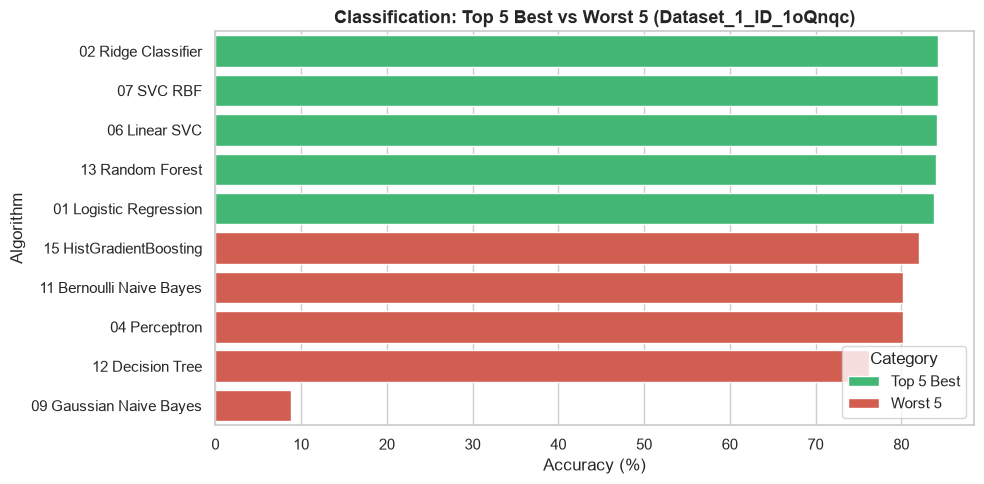


🥇 [Regression] Top 5 Best Algorithms (Lowest MAE):
   • 20 Huber Regressor: MAE = 0.3027
   • 22 Support Vector Regression: MAE = 0.3664
   • 23 K-Nearest Neighbors Regressor: MAE = 0.4079
   • 28 Gradient Boosting Regressor: MAE = 0.4247
   • 26 Extra Trees Regressor: MAE = 0.4317

🔻 [Regression] Top 5 Worst Algorithms (Highest MAE):
   • 30 Poisson Regressor: MAE = 0.4539
   • 27 HistGradientBoosting Regressor: MAE = 0.4540
   • 18 Lasso Regression: MAE = 0.4887
   • 19 Elastic Net: MAE = 0.4887
   • 29 AdaBoost Regressor: MAE = 0.5628


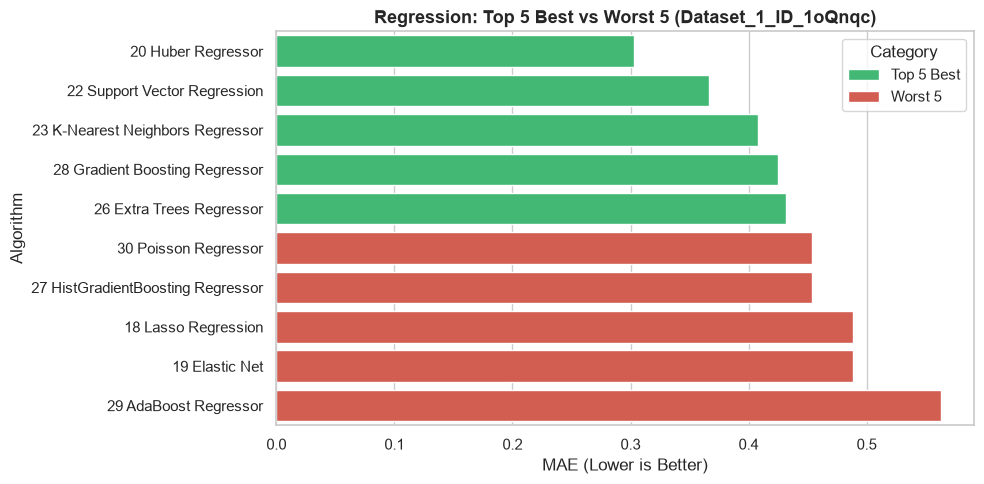


🥇 [Clustering] Top 5 Best Algorithms (Highest Silhouette):
   • 39 Spectral Clustering: Silhouette = 0.2759
   • 38 Mean Shift: Silhouette = 0.2091
   • 40 Gaussian Mixture: Silhouette = 0.1887
   • 31 K-Means: Silhouette = 0.1795
   • 35 Birch: Silhouette = 0.1714

🔻 [Clustering] Top 5 Worst Algorithms (Lowest Silhouette):
   • 35 Birch: Silhouette = 0.1714
   • 34 Agglomerative Clustering: Silhouette = 0.1635
   • 32 Mini-Batch K-Means: Silhouette = 0.0726
   • 33 Bisecting K-Means: Silhouette = 0.0622
   • 37 OPTICS: Silhouette = -0.1553


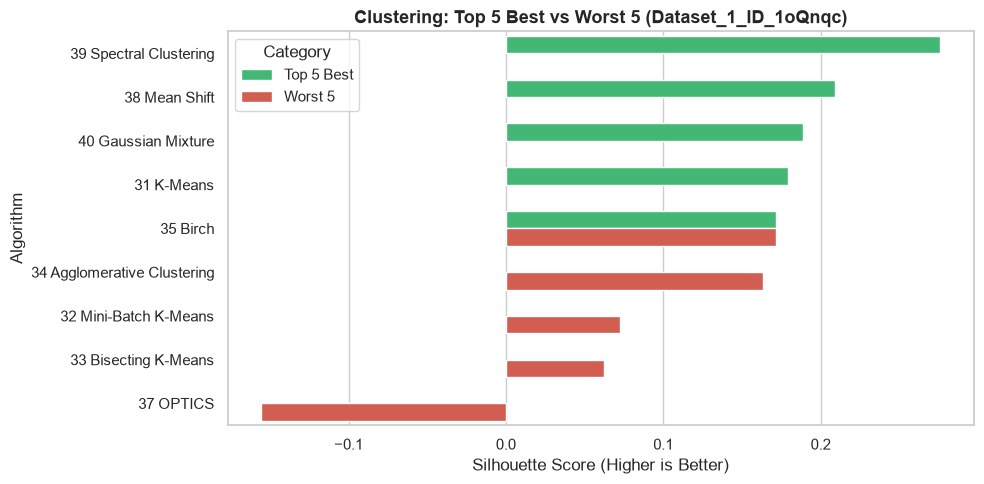


📊 Dataset: Dataset_2_ID_1YB7Oz

🥇 [Classification] Top 5 Best Algorithms:
   • 02 Ridge Classifier: 32.58% Accuracy
   • 06 Linear SVC: 32.48% Accuracy
   • 01 Logistic Regression: 32.12% Accuracy
   • 07 SVC RBF: 32.01% Accuracy
   • 10 Multinomial Naive Bayes: 30.79% Accuracy

🔻 [Classification] Top 5 Worst Algorithms:
   • 12 Decision Tree: 23.62% Accuracy
   • 05 Passive Aggressive: 23.06% Accuracy
   • 03 SGD Classifier: 21.53% Accuracy
   • 04 Perceptron: 20.55% Accuracy
   • 09 Gaussian Naive Bayes: 12.87% Accuracy


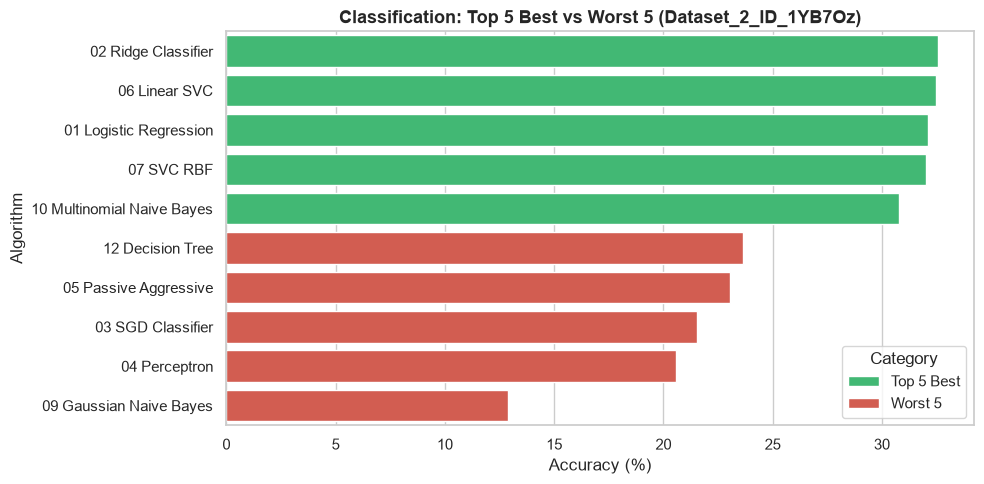


🥇 [Regression] Top 5 Best Algorithms (Lowest MAE):
   • 22 Support Vector Regression: MAE = 1.3749
   • 20 Huber Regressor: MAE = 1.3876
   • 28 Gradient Boosting Regressor: MAE = 1.3896
   • 16 Linear Regression: MAE = 1.4010
   • 17 Ridge Regression: MAE = 1.4010

🔻 [Regression] Top 5 Worst Algorithms (Highest MAE):
   • 23 K-Nearest Neighbors Regressor: MAE = 1.5170
   • 29 AdaBoost Regressor: MAE = 1.5575
   • 19 Elastic Net: MAE = 1.6754
   • 18 Lasso Regression: MAE = 1.8557
   • 24 Decision Tree Regressor: MAE = 1.8615


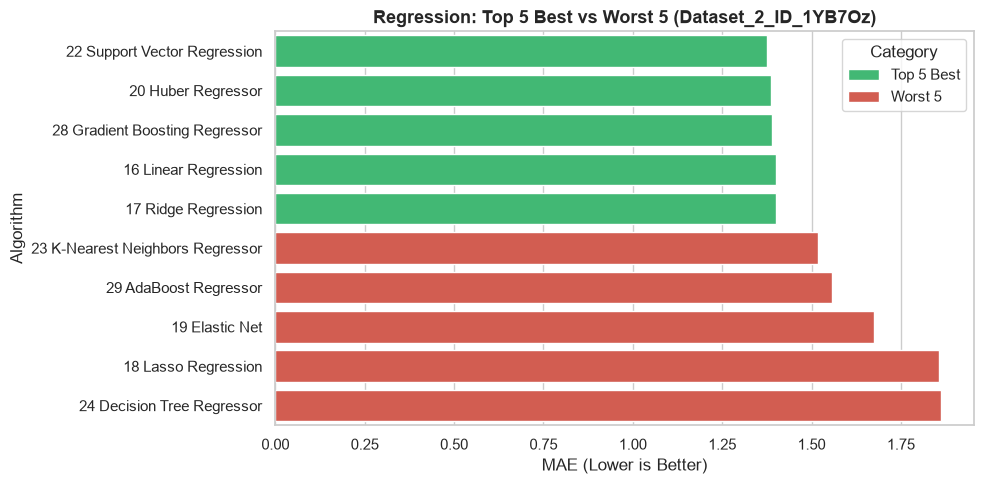


🥇 [Clustering] Top 5 Best Algorithms (Highest Silhouette):
   • 39 Spectral Clustering: Silhouette = 0.2370
   • 40 Gaussian Mixture: Silhouette = 0.2012
   • 38 Mean Shift: Silhouette = 0.1915
   • 31 K-Means: Silhouette = 0.1465
   • 35 Birch: Silhouette = 0.1203

🔻 [Clustering] Top 5 Worst Algorithms (Lowest Silhouette):
   • 35 Birch: Silhouette = 0.1203
   • 34 Agglomerative Clustering: Silhouette = 0.1143
   • 33 Bisecting K-Means: Silhouette = 0.0977
   • 32 Mini-Batch K-Means: Silhouette = 0.0777
   • 37 OPTICS: Silhouette = -0.1936


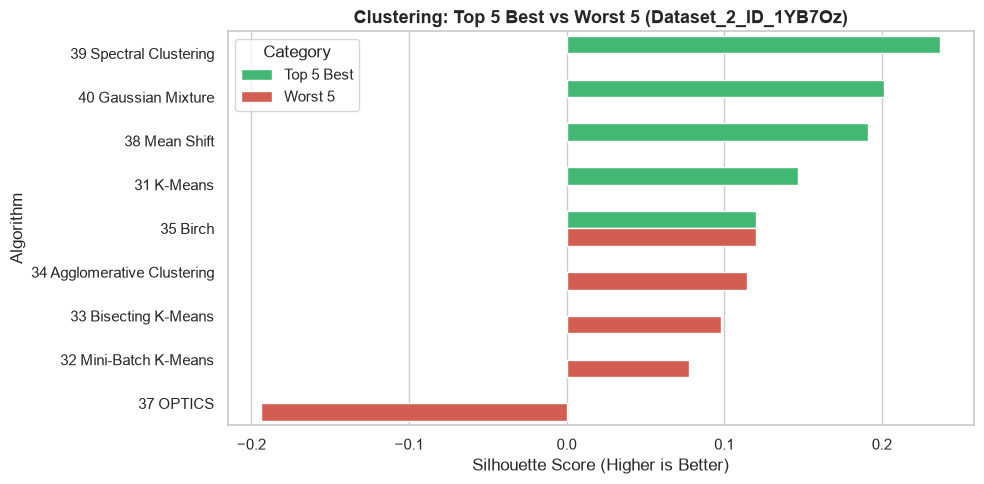


📊 Dataset: Dataset_3_ID_1caYPh

🥇 [Classification] Top 5 Best Algorithms:
   • 02 Ridge Classifier: 37.41% Accuracy
   • 06 Linear SVC: 37.28% Accuracy
   • 01 Logistic Regression: 36.97% Accuracy
   • 07 SVC RBF: 36.79% Accuracy
   • 10 Multinomial Naive Bayes: 35.68% Accuracy

🔻 [Classification] Top 5 Worst Algorithms:
   • 08 K-Nearest Neighbors: 30.80% Accuracy
   • 12 Decision Tree: 27.52% Accuracy
   • 04 Perceptron: 27.44% Accuracy
   • 09 Gaussian Naive Bayes: 26.42% Accuracy
   • 05 Passive Aggressive: 18.64% Accuracy


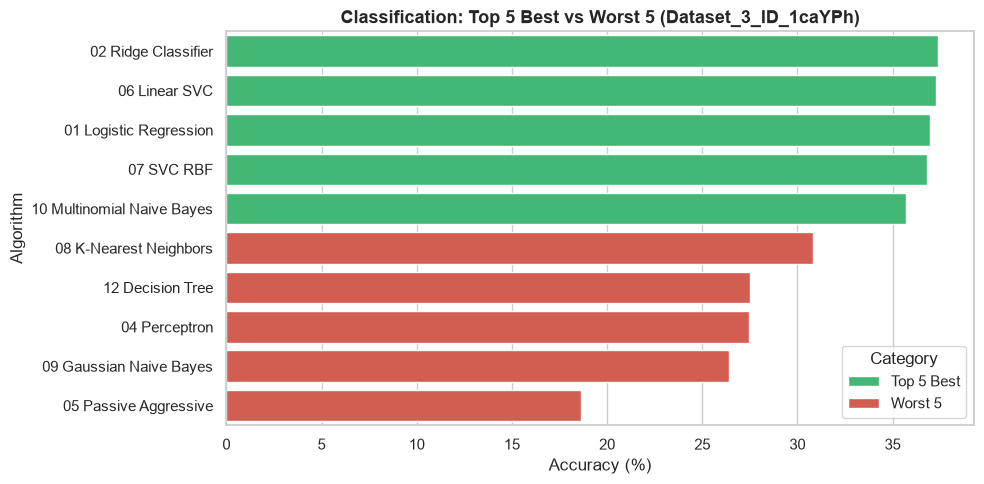


🥇 [Regression] Top 5 Best Algorithms (Lowest MAE):
   • 22 Support Vector Regression: MAE = 1.3077
   • 20 Huber Regressor: MAE = 1.3162
   • 17 Ridge Regression: MAE = 1.3306
   • 16 Linear Regression: MAE = 1.3306
   • 21 SGD Regressor: MAE = 1.3333

🔻 [Regression] Top 5 Worst Algorithms (Highest MAE):
   • 26 Extra Trees Regressor: MAE = 1.4322
   • 29 AdaBoost Regressor: MAE = 1.5326
   • 19 Elastic Net: MAE = 1.5766
   • 18 Lasso Regression: MAE = 1.7102
   • 24 Decision Tree Regressor: MAE = 1.7177


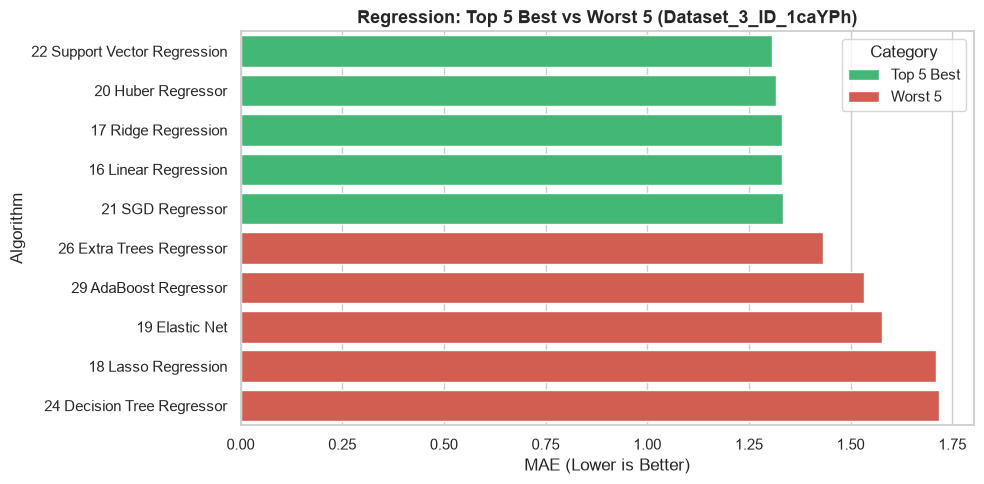


🥇 [Clustering] Top 5 Best Algorithms (Highest Silhouette):
   • 39 Spectral Clustering: Silhouette = 0.2734
   • 38 Mean Shift: Silhouette = 0.2102
   • 40 Gaussian Mixture: Silhouette = 0.1477
   • 35 Birch: Silhouette = 0.1366
   • 34 Agglomerative Clustering: Silhouette = 0.1330

🔻 [Clustering] Top 5 Worst Algorithms (Lowest Silhouette):
   • 34 Agglomerative Clustering: Silhouette = 0.1330
   • 31 K-Means: Silhouette = 0.0881
   • 32 Mini-Batch K-Means: Silhouette = 0.0880
   • 33 Bisecting K-Means: Silhouette = 0.0811
   • 37 OPTICS: Silhouette = -0.1840


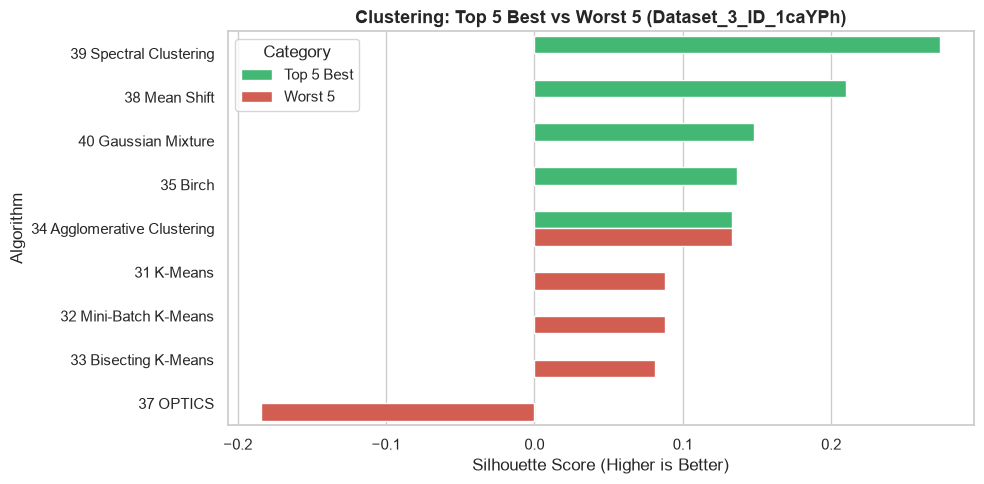


📊 ALL ALGORITHMS OVERALL COMPARISON


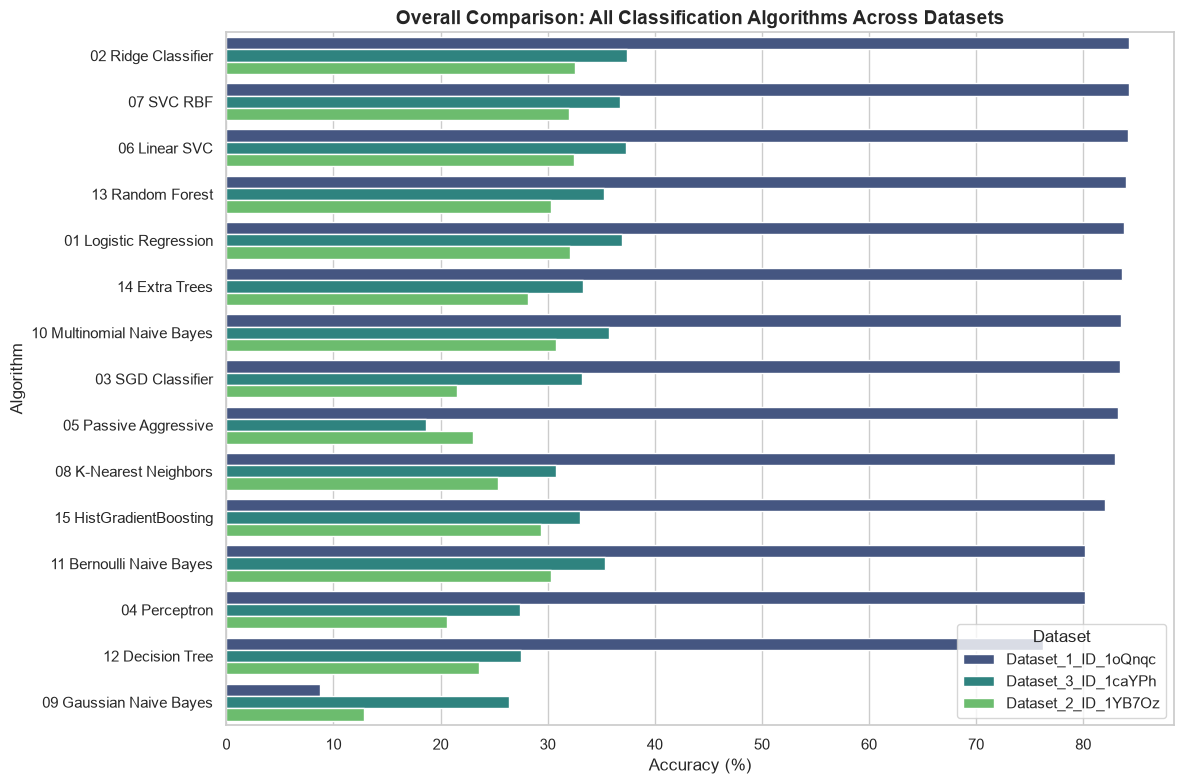

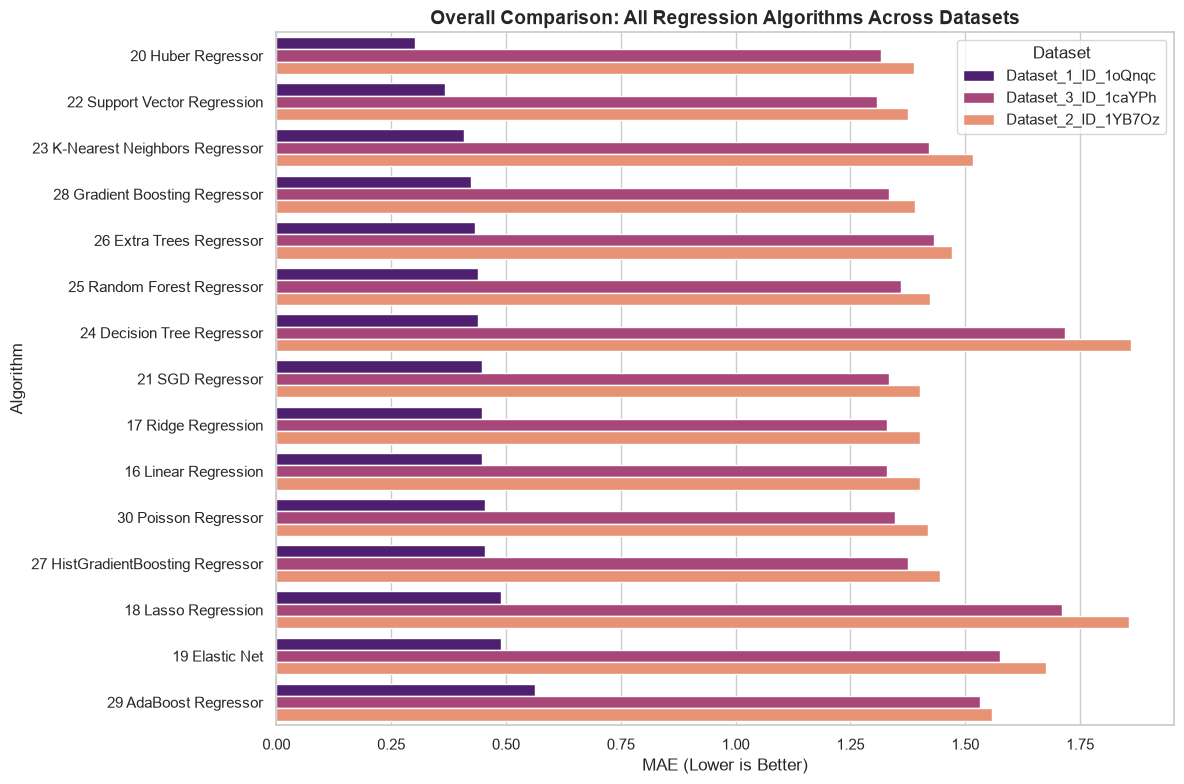

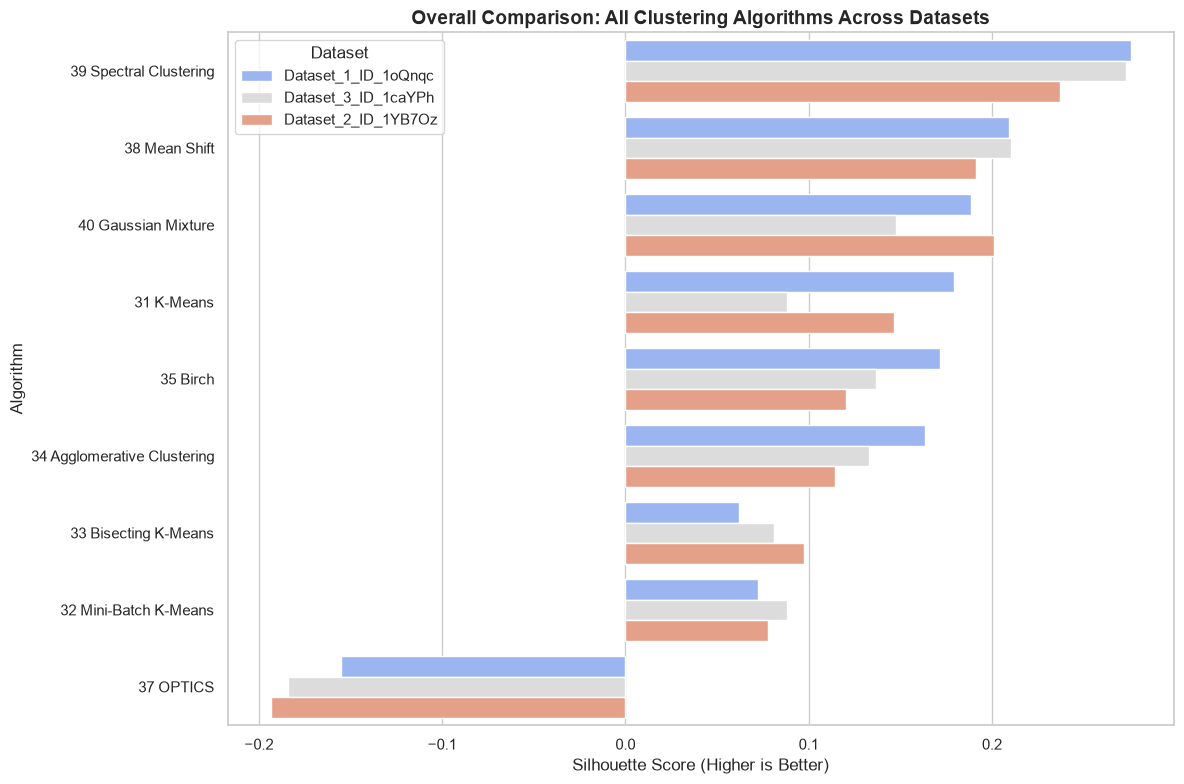

In [13]:
# ==========================================
# Cell 7: Extract the Top and Bottom 5 Algorithms + Overall and Per-Dataset Plots
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("🏆 PERFORMANCE REPORT (Top 5 & Worst 5 Algorithms per Dataset):\n")

for ds_name in results_df['dataset'].unique():
    print(f"\n==========================================")
    print(f"📊 Dataset: {ds_name}")
    print(f"==========================================")

    ds_results = results_df[(results_df['dataset'] == ds_name) & (results_df['status'] == 'success')]

    # --------------------------------------------------
    # 1. Classification
    # --------------------------------------------------
    clf = ds_results[ds_results['category'] == 'Classification'].sort_values('accuracy_percent', ascending=False)
    if not clf.empty:
        top5_clf = clf.head(5)
        worst5_clf = clf.tail(5)

        print("\n🥇 [Classification] Top 5 Best Algorithms:")
        for idx, row in top5_clf.iterrows():
            print(f"   • {row['algorithm']}: {row['accuracy_percent']:.2f}% Accuracy")

        print("\n🔻 [Classification] Top 5 Worst Algorithms:")
        for idx, row in worst5_clf.iterrows():
            print(f"   • {row['algorithm']}: {row['accuracy_percent']:.2f}% Accuracy")

        # Plot the Top and Bottom 5 Classification Algorithms
        top_worst_clf = pd.concat([top5_clf.assign(Group='Top 5 Best'), worst5_clf.assign(Group='Worst 5')])
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_worst_clf, x='accuracy_percent', y='algorithm', hue='Group', palette={'Top 5 Best': '#2ecc71', 'Worst 5': '#e74c3c'})
        plt.title(f"Classification: Top 5 Best vs Worst 5 ({ds_name})", fontsize=13, fontweight='bold')
        plt.xlabel("Accuracy (%)")
        plt.ylabel("Algorithm")
        plt.legend(title="Category")
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # 2. Regression
    # --------------------------------------------------
    reg = ds_results[ds_results['category'] == 'Regression'].sort_values('mae', ascending=True)
    if not reg.empty:
        top5_reg = reg.head(5)
        worst5_reg = reg.tail(5)

        print("\n🥇 [Regression] Top 5 Best Algorithms (Lowest MAE):")
        for idx, row in top5_reg.iterrows():
            print(f"   • {row['algorithm']}: MAE = {row['mae']:.4f}")

        print("\n🔻 [Regression] Top 5 Worst Algorithms (Highest MAE):")
        for idx, row in worst5_reg.iterrows():
            print(f"   • {row['algorithm']}: MAE = {row['mae']:.4f}")

        # Plot the Top and Bottom 5 Regression Algorithms
        top_worst_reg = pd.concat([top5_reg.assign(Group='Top 5 Best'), worst5_reg.assign(Group='Worst 5')])
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_worst_reg, x='mae', y='algorithm', hue='Group', palette={'Top 5 Best': '#2ecc71', 'Worst 5': '#e74c3c'})
        plt.title(f"Regression: Top 5 Best vs Worst 5 ({ds_name})", fontsize=13, fontweight='bold')
        plt.xlabel("MAE (Lower is Better)")
        plt.ylabel("Algorithm")
        plt.legend(title="Category")
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # 3. Clustering
    # --------------------------------------------------
    clust = ds_results[(ds_results['category'] == 'Clustering') & (ds_results['silhouette'].notna())].sort_values('silhouette', ascending=False)
    if not clust.empty:
        top5_clust = clust.head(5)
        worst5_clust = clust.tail(5)

        print("\n🥇 [Clustering] Top 5 Best Algorithms (Highest Silhouette):")
        for idx, row in top5_clust.iterrows():
            print(f"   • {row['algorithm']}: Silhouette = {row['silhouette']:.4f}")

        print("\n🔻 [Clustering] Top 5 Worst Algorithms (Lowest Silhouette):")
        for idx, row in worst5_clust.iterrows():
            print(f"   • {row['algorithm']}: Silhouette = {row['silhouette']:.4f}")

        # Plot the Top and Bottom 5 Clustering Algorithms
        top_worst_clust = pd.concat([top5_clust.assign(Group='Top 5 Best'), worst5_clust.assign(Group='Worst 5')])
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_worst_clust, x='silhouette', y='algorithm', hue='Group', palette={'Top 5 Best': '#2ecc71', 'Worst 5': '#e74c3c'})
        plt.title(f"Clustering: Top 5 Best vs Worst 5 ({ds_name})", fontsize=13, fontweight='bold')
        plt.xlabel("Silhouette Score (Higher is Better)")
        plt.ylabel("Algorithm")
        plt.legend(title="Category")
        plt.tight_layout()
        plt.show()


# ==================================================
# 🌐 Comprehensive Comparison Chart of All Algorithms
# ==================================================
print("\n==========================================")
print("📊 ALL ALGORITHMS OVERALL COMPARISON")
print("==========================================")

# 1. Comprehensive Chart of All Classification Algorithms
clf_all = results_df[(results_df['category'] == 'Classification') & (results_df['status'] == 'success')].sort_values('accuracy_percent', ascending=False)
if not clf_all.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(data=clf_all, x='accuracy_percent', y='algorithm', hue='dataset', palette='viridis')
    plt.title("Overall Comparison: All Classification Algorithms Across Datasets", fontsize=14, fontweight='bold')
    plt.xlabel('Accuracy (%)')
    plt.ylabel('Algorithm')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()


# 2. Comprehensive Chart of All Regression Algorithms
reg_all = results_df[(results_df['category'] == 'Regression') & (results_df['status'] == 'success')].sort_values('mae', ascending=True)
if not reg_all.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(data=reg_all, x='mae', y='algorithm', hue='dataset', palette='magma')
    plt.title("Overall Comparison: All Regression Algorithms Across Datasets", fontsize=14, fontweight='bold')
    plt.xlabel('MAE (Lower is Better)')
    plt.ylabel('Algorithm')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()

# 3. Comprehensive Chart of All Clustering Algorithms
clust_all = results_df[(results_df['category'] == 'Clustering') & (results_df['status'] == 'success') & (results_df['silhouette'].notna())].sort_values('silhouette', ascending=False)
if not clust_all.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(data=clust_all, x='silhouette', y='algorithm', hue='dataset', palette='coolwarm')
    plt.title("Overall Comparison: All Clustering Algorithms Across Datasets", fontsize=14, fontweight='bold')
    plt.xlabel('Silhouette Score (Higher is Better)')
    plt.ylabel('Algorithm')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()